# `Runtimedata` quick-look

A notebook that uses the **hst** postprocessing tools in `post/` to plot the
quantities that the DNS logs into `Runtimedata` — one line every `dt_stat`,
holding the 13 CPL columns — and, if present, the per-component velocity
variances in `variances_runtime.dat`.

It only wires together the public API of the tools (`post.load_config`,
`post.read_runtimedata`, `post.read_variances`); the reading logic, column
naming and any binary-format knowledge stay in `post/io.py`.

> **Prerequisites** beyond the repo: `numpy` and `matplotlib`.
> Run top-to-bottom (Kernel ▸ Restart & Run All).

Compare with the command-line tool it mirrors:

```bash
python3 -m post plot_stats run/hst.in --log -o statistics.png
```


## 0. Locate the tools

Make sure the repo's `post/` package is importable no matter where the
notebook or the kernel was started.  `post/` is taken to live in the first
ancestor directory of Jupyter's current working directory that contains it.


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "post" / "__init__.py").is_file():
    parent = REPO_ROOT.parent
    if parent == REPO_ROOT:
        raise RuntimeError("could not find the repo root (the directory containing post/)")
    REPO_ROOT = parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
from post import load_config, read_runtimedata, read_variances

print(f"using post/ tools from: {REPO_ROOT}")


using post/ tools from: /home/ws/th5982/research/codes/homogenenousShearTurbulence


## 1. Point at a run

Set `DECK` to an `hst.in` deck (or a directory that contains one).  The
`Runtimedata` (and `variances_runtime.dat`, if present) are read from the
*directory the deck lives in* — this is how the tools derive the "run
directory", so point here at the run you want to inspect.


In [2]:
# --- choose the run ----------------------------------------------------
DECK = REPO_ROOT / "run" / "hst.in"
# e.g. DECK = REPO_ROOT / "my_case" / "hst.in"

cfg = load_config(DECK)
print(f"run directory : {cfg.run_dir}")
print(f"deck          : {cfg.deck_path.name}")
print(f"Re = {cfg.re}    S = {cfg.S}    mesh (nx, ny, nz) = ({cfg.nx}, {cfg.ny}, {cfg.nz})")
print(f"box  Lx : Ly : Lz = {cfg.lx:.4f} : {cfg.ly:.4f} : {cfg.lz:.4f}")
print(f"t0 = {cfg.time}    dt_stat = {cfg.dt_stat}")


run directory : /home/ws/th5982/research/codes/homogenenousShearTurbulence/run
deck          : hst.in
Re = 1000.0    S = 1.0    mesh (nx, ny, nz) = (65, 86, 22)
box  Lx : Ly : Lz = 3.0000 : 2.0000 : 1.0000
t0 = 0.0    dt_stat = 0.01


## 2. Load the runtime data

`post.read_runtimedata` returns a *structured* numpy array: each of the 13
columns is a named field, so `rt["energy"]`, `rt["time"]`, … work directly.
The column order is unchanged from CPL's `Runtimedata`.


In [3]:
rt_path = cfg.run_dir / "Runtimedata"
rt = read_runtimedata(rt_path)
print(f"loaded '{rt_path.name}': {len(rt)} rows, time in "
      f"[{rt['time'].min():.5f}, {rt['time'].max():.5f}]")
print()

gloss = {
    "time":      "simulation time",
    "meanflowx": "streamwise mean-flow integral",
    "meanflowy": "vertical mean-flow integral",
    "S":         "mean shear  dU/dy",
    "S2":        "spanwise shear  dW/dy  (0 unless an S2 / Stokes term is active)",
    "gamma_x":   "streamwise shear displacement  gamma_x = S t",
    "gamma_y":   "spanwise shear displacement  gamma_y",
    "deltat":    "adopted time step",
    "cfl_dt":    "CFL-limited time step  cflmax * dt",
    "energy":    "turbulent kinetic energy  <u_i u_i>/2  (ly/2 box-weighted)",
    "diss":      "dissipation  <∂_j u_i ∂_j u_i>/2",
    "uw2":       "Reynolds stress  <u v>/2",
    "vw2":       "Reynolds stress  <v w>/2",
}
print("col  name         quantity")
for i, name in enumerate(rt.dtype.names, 1):
    print(f"{i:>3}  {name:<12} {gloss.get(name, '')}")


loaded 'Runtimedata': 2051 rows, time in [0.00000, 20.49995]

col  name         quantity
  1  time         simulation time
  2  meanflowx    streamwise mean-flow integral
  3  meanflowy    vertical mean-flow integral
  4  S            mean shear  dU/dy
  5  S2           spanwise shear  dW/dy  (0 unless an S2 / Stokes term is active)
  6  gamma_x      streamwise shear displacement  gamma_x = S t
  7  gamma_y      spanwise shear displacement  gamma_y
  8  deltat       adopted time step
  9  cfl_dt       CFL-limited time step  cflmax * dt
 10  energy       turbulent kinetic energy  <u_i u_i>/2  (ly/2 box-weighted)
 11  diss         dissipation  <∂_j u_i ∂_j u_i>/2
 12  uw2          Reynolds stress  <u v>/2
 13  vw2          Reynolds stress  <v w>/2


In [4]:
# A quick numeric preview: first and last rows.
cols = rt.dtype.names
for tag, row in (("first", 0), ("last", -1)):
    print(f"{tag:>5}: " + "  ".join(f"{col}={rt[col][row]: .6g}" for col in cols))


first: time= 0  meanflowx=-1.07483e-14  meanflowy=-6.07153e-16  S= 1  S2= 0  gamma_x= 0  gamma_y= 0  deltat= 0.00425257  cfl_dt= 0.5  energy= 0.120491  diss= 23.9656  uw2=-0.0176376  vw2=-0.000475832
 last: time= 20.4999  meanflowx=-2.17881e-15  meanflowy=-2.79117e-15  S= 1  S2= 0  gamma_x= 20.4999  gamma_y= 0  deltat= 0.000728068  cfl_dt= 0.5  energy= 0.0889245  diss= 17.5913  uw2=-0.013534  vw2=-0.00141152


## 3. Plot the `Runtimedata` quantities

Everything below is a time series against `rt["time"]`.  The panels mirror
`post run plot_stats` but show **all** the logged quantities, so:
energy/dissipation, Reynolds stresses, timestep, mean-flow integrals, the
shear kinematics (`S`, `S2`, and the two displacement angles), plus the
per-component variances from `variances_runtime.dat` when it exists.


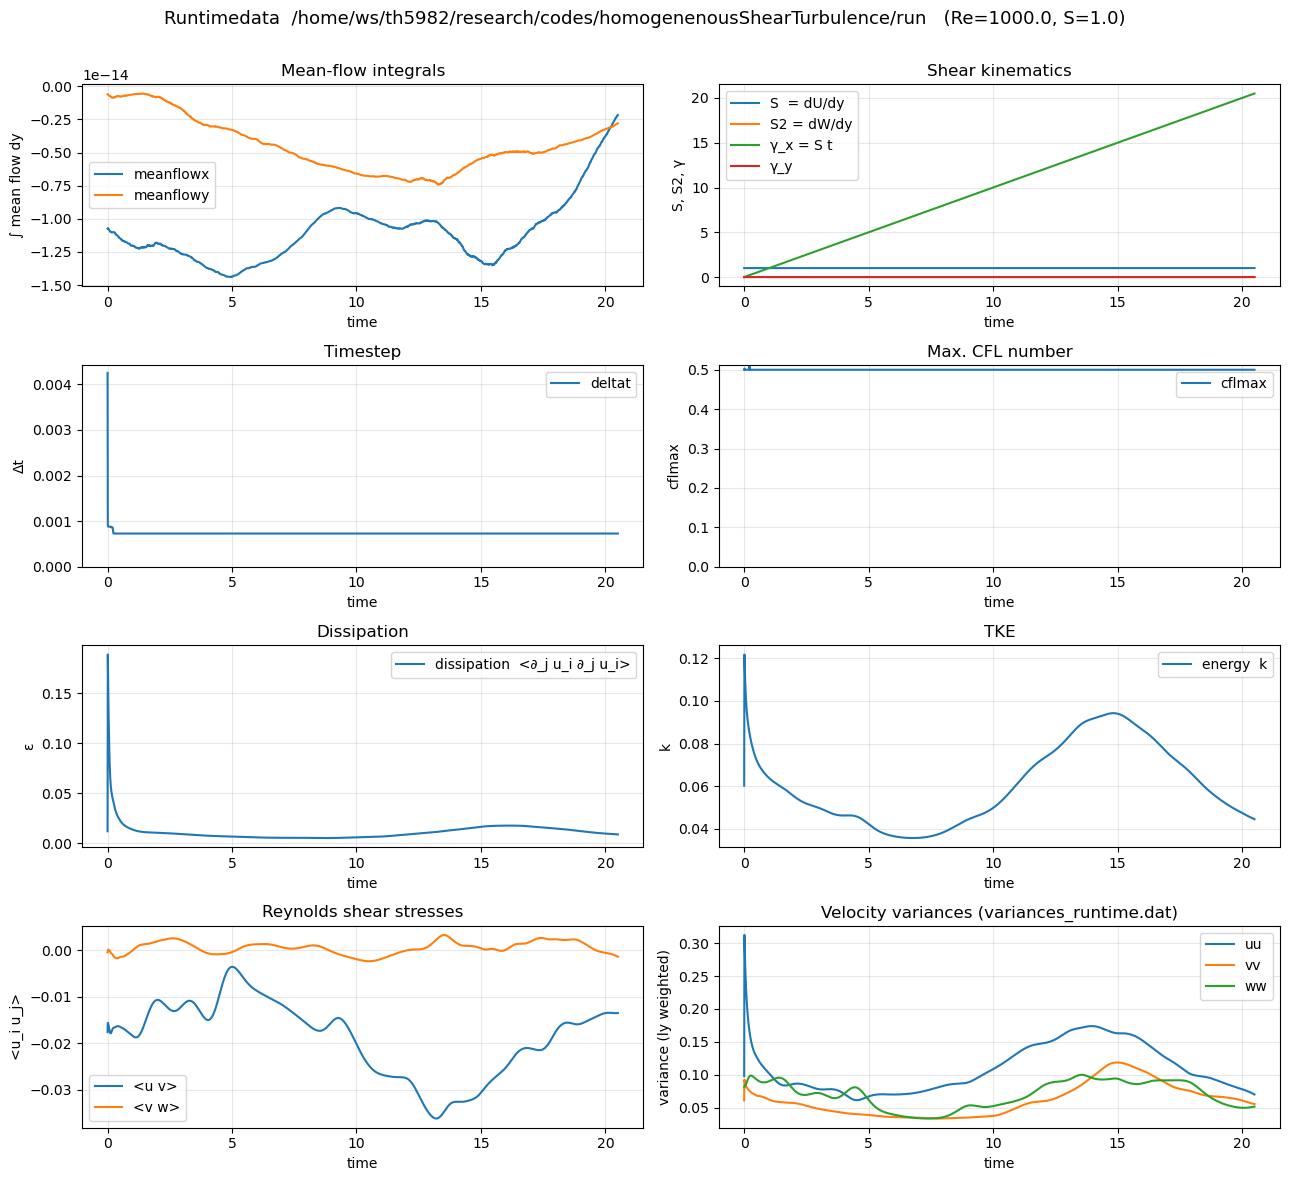

In [5]:
import matplotlib
import matplotlib.pyplot as plt

# Inline backend so figures are embedded; harmless under nbconvert too.
%matplotlib inline

t = rt["time"]
fig, axes = plt.subplots(4, 2, figsize=(13, 12))
fig.suptitle(f"Runtimedata  {cfg.run_dir}   (Re={cfg.re}, S={cfg.S})", fontsize=13)

def finish(ax, title, ylabel):
    ax.set_title(title)
    ax.set_xlabel("time")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

# (0,0) mean flow -------------------------------------------------------------
ax = axes[0, 0]
ax.plot(t, rt["meanflowx"], label="meanflowx")
ax.plot(t, rt["meanflowy"], label="meanflowy")
finish(ax, "Mean-flow integrals", "∫ mean flow dy")

# (0,1) shear kinematics -----------------------------------------------------
ax = axes[0, 1]
ax.plot(t, rt["S"],       label="S  = dU/dy")
ax.plot(t, rt["S2"],      label="S2 = dW/dy")
ax.plot(t, rt["gamma_x"], label="γ_x = S t")
ax.plot(t, rt["gamma_y"], label="γ_y")
finish(ax, "Shear kinematics", "S, S2, γ")

# (1,0) timestep --------------------------------------------------------------
ax = axes[1, 0]
ax.plot(t, rt["deltat"], label="deltat")
ax.set_ylim(bottom=0)
finish(ax, "Timestep", "Δt")

# (1,1) cfl -------------------------------------------------------------------
ax = axes[1, 1]
ax.plot(t, rt["cfl_dt"], label="cflmax")
ax.set_ylim(bottom=0)
finish(ax, "Max. CFL number", "cflmax")


# (2,0) dissipation -----------------------------------------------------------
# compute kinematic viscosity
nu = 1/cfg.re
ax = axes[2, 0]
ax.plot(t, 0.5*nu*rt["diss"],   label="dissipation  <∂_j u_i ∂_j u_i>")
finish(ax, "Dissipation", "ε")

# (2,1) tke ------------------------------------------------------------------
ax = axes[2, 1]
ax.plot(t, 0.5*rt["energy"], label="energy  k")
finish(ax, "TKE", "k")

# (3,0) Reynolds shear stresses ----------------------------------------------
ax = axes[3, 0]
ax.plot(t, rt["uw2"], label="<u v>")
ax.plot(t, rt["vw2"], label="<v w>")
finish(ax, "Reynolds shear stresses", "<u_i u_j>")


# (3,1) variances if present, else an energy–dissipation view -----------------
var_file = cfg.run_dir / "variances_runtime.dat"
ax = axes[3, 1]
if var_file.exists():
    var = read_variances(var_file)
    ax.plot(var["time"], var["uu"], label="uu")
    ax.plot(var["time"], var["vv"], label="vv")
    ax.plot(var["time"], var["ww"], label="ww")
    finish(ax, "Velocity variances (variances_runtime.dat)", "variance (ly weighted)")
else:
    ax.plot(rt["diss"], rt["energy"], ".", ms=3)
    ax.set_xlabel("dissipation"); ax.set_ylabel("energy")
    ax.set_title("energy vs dissipation"); ax.grid(True, alpha=0.3)

fig.tight_layout(rect=(0, 0, 1, 0.975))
plt.show()
